# Phase 3 — Prétraitement et Filtrage Qualité
## Images Merapi 2014–2018

**Pipeline** :
1. **3A** — Réconciliation de l'index (corriger le flag `downloaded`)
2. **3B** — Filtrage qualité (classifier chaque image : usable / dark / cloudy / corrupted)
3. **3C** — Prétraitement image (redimensionnement, normalisation, sauvegarde)
4. **3D** — Mise à jour de l'index et rapport final

**Garde-fous** :
- Traitement mois par mois avec tqdm
- Plafond configurable par mois (`MAX_PER_MONTH`)
- Chaque étape peut être relancée indépendamment (idempotent)
- Cellules annotées `[LÉGER]` / `[MOYEN]` / `[COÛTEUX]`

In [1]:
# [LÉGER] — Imports et configuration
import sys, os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Détection racine projet
NOTEBOOK_DIR = Path(os.getcwd())
if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config, setup_logger
from src.indexer import MerapiIndexer
from src.quality_filter import QualityFilter
from src.preprocessing import MerapiPreprocessor

config = load_config()
setup_logger(config)

INDEX_PATH = PROJECT_ROOT / config["paths"]["index_file"]
RAW_DIR = PROJECT_ROOT / config["paths"]["data_raw"]
PROC_DIR = PROJECT_ROOT / config["paths"]["data_processed"]

# --- PARAMÈTRES AJUSTABLES ---
YEAR_START = 2014
YEAR_END = 2018
MAX_PER_MONTH = None   # None = traiter tout, ou un int (ex: 200) pour limiter

print(f"Projet      : {PROJECT_ROOT}")
print(f"Index       : {INDEX_PATH}")
print(f"Raw         : {RAW_DIR}")
print(f"Processed   : {PROC_DIR}")
print(f"Plage       : {YEAR_START}–{YEAR_END}")
print(f"Plafond/mois: {MAX_PER_MONTH or 'illimité'}")

15:57:37 | INFO     | src.utils:163 — Logger initialisé — niveau : INFO


Projet      : /Users/knightpetersonjean-baptiste/Desktop/Stage_M2/Projet_Diffusion/Volcan_search/merapi_anomaly
Index       : /Users/knightpetersonjean-baptiste/Desktop/Stage_M2/Projet_Diffusion/Volcan_search/merapi_anomaly/data/index/index.csv
Raw         : /Users/knightpetersonjean-baptiste/Desktop/Stage_M2/Projet_Diffusion/Volcan_search/merapi_anomaly/data/raw
Processed   : /Users/knightpetersonjean-baptiste/Desktop/Stage_M2/Projet_Diffusion/Volcan_search/merapi_anomaly/data/processed
Plage       : 2014–2018
Plafond/mois: illimité


---
## 3A — Réconciliation de l'index

Le flag `downloaded` dans l'index est obsolète (seul 2018 était marqué).  
On vérifie l'existence réelle de chaque fichier et on corrige l'index.

In [2]:
# [MOYEN] — Réconciliation index (~30 sec pour 27K entrées)
indexer = MerapiIndexer(config)
df = indexer.load()

# État avant
n_before = df["downloaded"].sum() if "downloaded" in df.columns else 0
print(f"Avant réconciliation : {n_before} images marquées 'downloaded'")
print(f"Total dans l'index   : {len(df):,}")

# Réconcilier
df = QualityFilter.reconcile_index(df, config)

# État après
n_after = df["downloaded"].sum()
print(f"\nAprès réconciliation : {n_after} images trouvées sur disque")
print(f"Delta                : +{n_after - n_before}")

# Par année
print("\nPar année :")
for y in range(YEAR_START, YEAR_END + 1):
    mask = (df["year"] == y) & (df["downloaded"] == True)
    print(f"  {y} : {mask.sum():,} fichiers trouvés")

# Sauvegarder l'index réconcilié
indexer._save(df)
print("\n✓ Index sauvegardé.")

Avant réconciliation : 25083 images marquées 'downloaded'
Total dans l'index   : 27,098


15:57:46 | INFO     | src.quality_filter:316 — Index réconcilié : 25083 fichiers trouvés sur disque



Après réconciliation : 25083 images trouvées sur disque
Delta                : +0

Par année :
  2014 : 844 fichiers trouvés
  2015 : 2,286 fichiers trouvés
  2016 : 7,805 fichiers trouvés
  2017 : 6,965 fichiers trouvés
  2018 : 5,915 fichiers trouvés

✓ Index sauvegardé.


---
## 3B — Filtrage qualité

Classification de chaque image en `usable`, `dark`, `cloudy` ou `corrupted`.  
Basée sur : luminosité moyenne, variance, entropie, taille fichier.  

**Seuils actuels** (depuis `settings.yaml`) :
- `dark` : luminosité < 30
- `cloudy` : variance < 50  
- `corrupted` : fichier < 1000 bytes ou illisible
- `usable` : tout le reste

In [3]:
# [COÛTEUX] — Classification qualité mois par mois (~2-5 min pour tout 2014-2018)
#
# CONSEIL : lancer d'abord sur un mois test pour vérifier les seuils,
# puis décommenter la boucle complète.

qf = QualityFilter(config)

# --- TEST sur un seul mois ---
test_results = qf.classify_month(2017, 6, max_images=50)
if test_results:
    report = qf.quality_report(test_results)
    print("\nRapport qualité (test 2017-06, 50 images) :")
    for k, v in report.items():
        if isinstance(v, dict):
            print(f"  {k}: {v}")
        elif isinstance(v, float):
            print(f"  {k}: {v:.3f}")
        else:
            print(f"  {k}: {v}")

15:57:49 | INFO     | src.quality_filter:216 — Plafond appliqué : 50/296 images
15:57:49 | INFO     | src.quality_filter:219 — Classification qualité de 50 images — 2017/06
Qualité 2017/06: 100%|██████████| 50/50 [00:00<00:00, 809.21img/s]
15:57:49 | INFO     | src.quality_filter:447 — Qualité 2017/06 (50 images) :
15:57:49 | INFO     | src.quality_filter:450 —   usable       :   48  (96.0%)
15:57:49 | INFO     | src.quality_filter:450 —   dark         :    2  (4.0%)
15:57:49 | INFO     | src.quality_filter:451 —   Taux utilisables : 96.0%



Rapport qualité (test 2017-06, 50 images) :
  total: 50
  by_quality: {'usable': 48, 'dark': 2}
  usable_rate: 0.960
  night_rate: 0.040
  cloudy_rate: 0.000
  corrupted_rate: 0.000
  mean_brightness_mean: 100.208
  mean_brightness_std: 57.928
  mean_brightness_min: 28.428
  mean_brightness_max: 236.358
  variance_mean: 1367.850
  variance_std: 1077.248
  variance_min: 325.575
  variance_max: 6952.895
  entropy_mean: 5.992
  entropy_std: 0.562
  entropy_min: 4.375
  entropy_max: 7.070


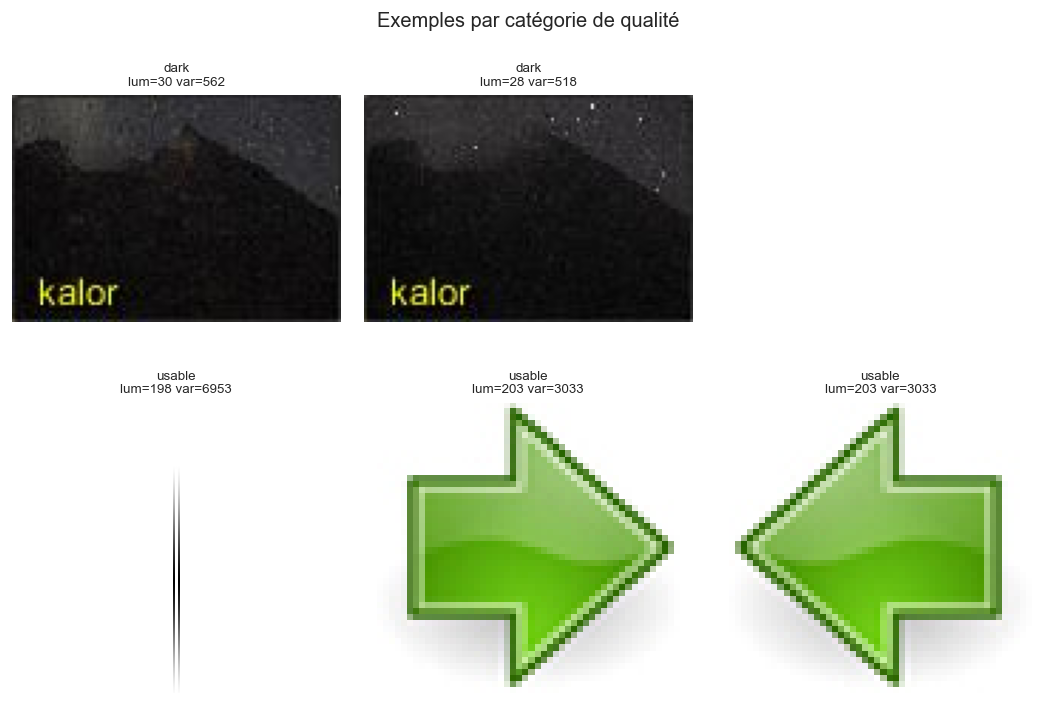

In [4]:
# [LÉGER] — Aperçu visuel : images par catégorie de qualité
from PIL import Image as PILImage

def show_quality_examples(results, n_per_cat=3):
    """Affiche quelques exemples par catégorie de qualité."""
    df_r = pd.DataFrame(results)
    categories = df_r["quality_flag"].unique()

    fig, axes = plt.subplots(
        len(categories), n_per_cat,
        figsize=(n_per_cat * 3, len(categories) * 3)
    )
    if len(categories) == 1:
        axes = axes[np.newaxis, :]

    for i, cat in enumerate(sorted(categories)):
        df_cat = df_r[df_r["quality_flag"] == cat]
        samples = df_cat.head(n_per_cat)
        for j in range(n_per_cat):
            ax = axes[i, j]
            if j < len(samples):
                row = samples.iloc[j]
                try:
                    img = PILImage.open(row["path"])
                    ax.imshow(img)
                    lum = f"lum={row['mean_brightness']:.0f}" if pd.notna(row.get('mean_brightness')) else ""
                    var = f"var={row['variance']:.0f}" if pd.notna(row.get('variance')) else ""
                    ax.set_title(f"{cat}\n{lum} {var}", fontsize=8)
                except Exception:
                    ax.text(0.5, 0.5, "Erreur", ha="center")
            ax.axis("off")

    plt.suptitle("Exemples par catégorie de qualité", fontsize=12)
    plt.tight_layout()
    plt.show()

if test_results:
    show_quality_examples(test_results)

In [5]:
# [COÛTEUX] — Classification complète 2014–2018
# Décommenter les lignes ci-dessous pour lancer sur toute la période.
# Temps estimé : ~2-5 min selon le nombre d'images sur disque.

all_quality_results = {}

for year in range(YEAR_START, YEAR_END + 1):
    for month in range(1, 13):
        key = f"{year}-{month:02d}"
        results = qf.classify_month(year, month, max_images=MAX_PER_MONTH)
        if results:
            all_quality_results[key] = results

# Résumé
total_classified = sum(len(v) for v in all_quality_results.values())
print(f"\nTotal classifié : {total_classified:,} images")
print(f"Mois traités    : {len(all_quality_results)}")

15:57:57 | INFO     | src.quality_filter:219 — Classification qualité de 2 images — 2014/01
Qualité 2014/01: 100%|██████████| 2/2 [00:00<00:00, 291.49img/s]
15:57:57 | INFO     | src.quality_filter:447 — Qualité 2014/01 (2 images) :
15:57:57 | INFO     | src.quality_filter:450 —   usable       :    2  (100.0%)
15:57:57 | INFO     | src.quality_filter:451 —   Taux utilisables : 100.0%
15:57:57 | INFO     | src.quality_filter:219 — Classification qualité de 2 images — 2014/02
Qualité 2014/02: 100%|██████████| 2/2 [00:00<00:00, 214.39img/s]
15:57:57 | INFO     | src.quality_filter:447 — Qualité 2014/02 (2 images) :
15:57:57 | INFO     | src.quality_filter:450 —   usable       :    2  (100.0%)
15:57:57 | INFO     | src.quality_filter:451 —   Taux utilisables : 100.0%
15:57:57 | INFO     | src.quality_filter:219 — Classification qualité de 2 images — 2014/03
Qualité 2014/03: 100%|██████████| 2/2 [00:00<00:00, 1119.23img/s]
15:57:57 | INFO     | src.quality_filter:447 — Qualité 2014/03 (2 im


Total classifié : 14,930 images
Mois traités    : 59


In [6]:
# [LÉGER] — Rapport qualité global
# Fusionner tous les résultats
all_results_flat = []
for results in all_quality_results.values():
    all_results_flat.extend(results)

global_report = qf.quality_report(all_results_flat)

print("=" * 50)
print("RAPPORT QUALITÉ GLOBAL 2014–2018")
print("=" * 50)
for k, v in global_report.items():
    if isinstance(v, dict):
        print(f"\n{k}:")
        for kk, vv in v.items():
            print(f"  {kk}: {vv}")
    elif isinstance(v, float):
        print(f"{k}: {v:.3f}")
    else:
        print(f"{k}: {v}")

RAPPORT QUALITÉ GLOBAL 2014–2018
total: 14930

by_quality:
  usable: 12137
  dark: 1888
  cloudy: 905
usable_rate: 0.813
night_rate: 0.126
cloudy_rate: 0.061
corrupted_rate: 0.000
mean_brightness_mean: 112.804
mean_brightness_std: 65.561
mean_brightness_min: 0.090
mean_brightness_max: 254.429
variance_mean: 1236.169
variance_std: 1263.681
variance_min: 0.087
variance_max: 10218.521
entropy_mean: 5.428
entropy_std: 1.640
entropy_min: 0.444
entropy_max: 7.835


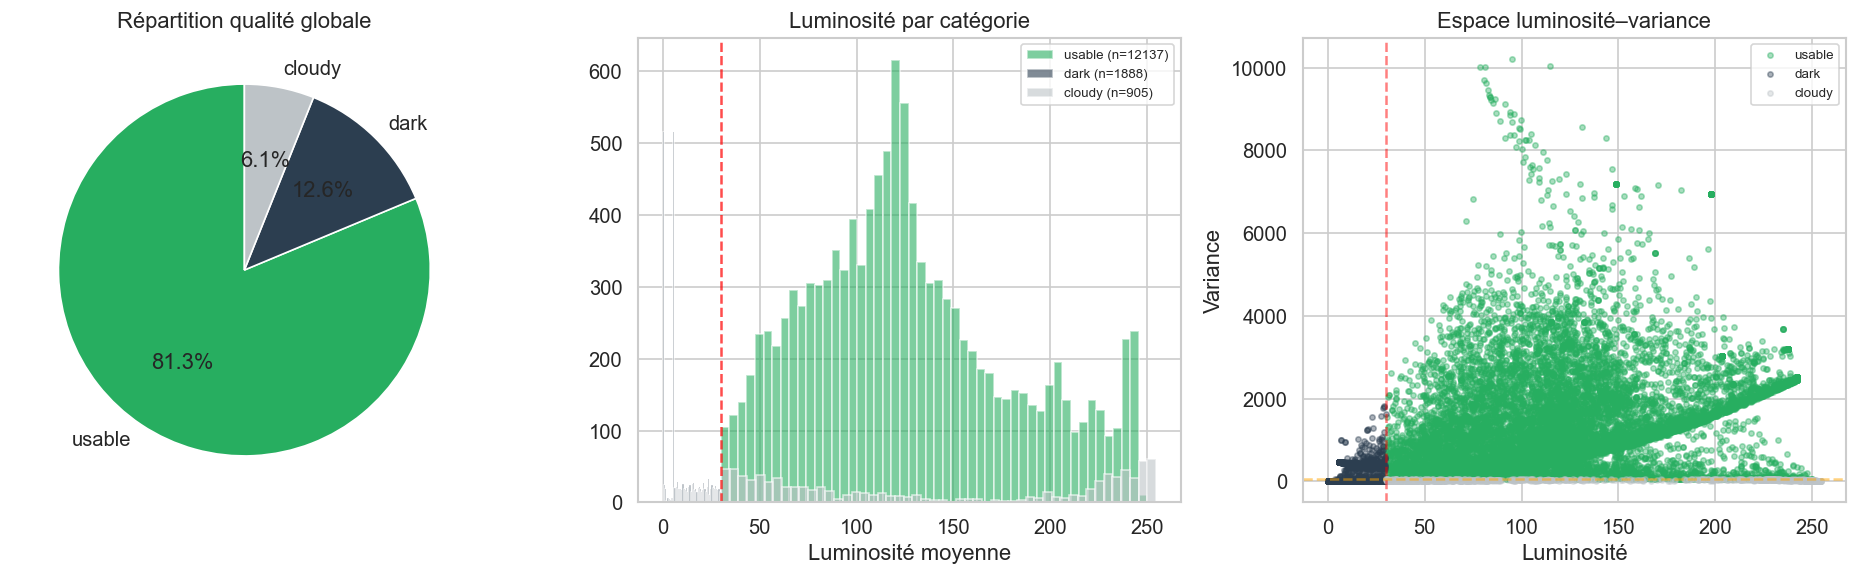

In [7]:
# [LÉGER] — Visualisation de la répartition qualité
df_all_q = pd.DataFrame(all_results_flat)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart global
qf_counts = df_all_q["quality_flag"].value_counts()
colors_q = {
    "usable": "#27ae60", "dark": "#2c3e50",
    "cloudy": "#bdc3c7", "corrupted": "#e74c3c", "unknown": "#f39c12"
}
pie_colors = [colors_q.get(c, "gray") for c in qf_counts.index]
axes[0].pie(
    qf_counts.values, labels=qf_counts.index,
    colors=pie_colors, autopct="%1.1f%%", startangle=90
)
axes[0].set_title("Répartition qualité globale")

# Histogramme luminosité par qualité
for qf_label in ["usable", "dark", "cloudy"]:
    subset = df_all_q[df_all_q["quality_flag"] == qf_label]["mean_brightness"].dropna()
    if not subset.empty:
        axes[1].hist(
            subset, bins=50, alpha=0.6,
            label=f"{qf_label} (n={len(subset)})",
            color=colors_q.get(qf_label, "gray")
        )
axes[1].axvline(30, color="red", ls="--", alpha=0.7)
axes[1].set_title("Luminosité par catégorie")
axes[1].set_xlabel("Luminosité moyenne")
axes[1].legend(fontsize=8)

# Scatter luminosité vs variance
for qf_label, color in colors_q.items():
    mask = df_all_q["quality_flag"] == qf_label
    if mask.any():
        axes[2].scatter(
            df_all_q.loc[mask, "mean_brightness"],
            df_all_q.loc[mask, "variance"],
            c=color, label=qf_label, alpha=0.4, s=10
        )
axes[2].axvline(30, color="red", ls="--", alpha=0.5)
axes[2].axhline(50, color="orange", ls="--", alpha=0.5)
axes[2].set_xlabel("Luminosité")
axes[2].set_ylabel("Variance")
axes[2].set_title("Espace luminosité–variance")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

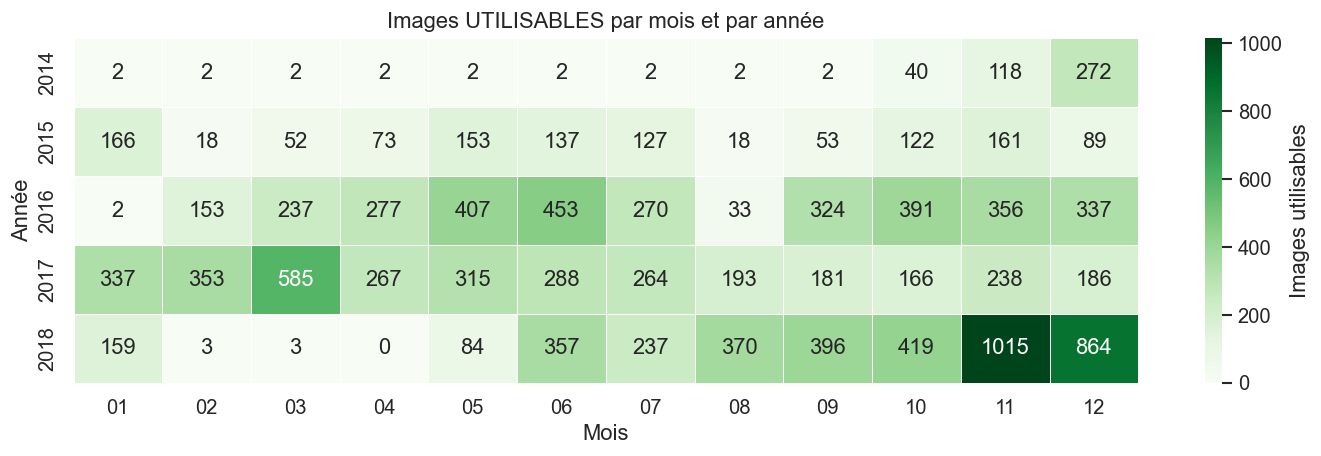

In [8]:
# [LÉGER] — Heatmap qualité par mois-année
# Extraire année/mois depuis les résultats
quality_by_month = []
for key, results in all_quality_results.items():
    year, month = key.split("-")
    df_r = pd.DataFrame(results)
    for qf_label in ["usable", "dark", "cloudy", "corrupted"]:
        count = (df_r["quality_flag"] == qf_label).sum()
        quality_by_month.append({
            "year": int(year), "month": int(month),
            "quality": qf_label, "count": count
        })

df_qm = pd.DataFrame(quality_by_month)

# Heatmap pour les images utilisables
df_usable = df_qm[df_qm["quality"] == "usable"].pivot(
    index="year", columns="month", values="count"
).fillna(0).astype(int)
for m in range(1, 13):
    if m not in df_usable.columns:
        df_usable[m] = 0
df_usable = df_usable[sorted(df_usable.columns)]
df_usable.columns = [f"{m:02d}" for m in df_usable.columns]

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    df_usable, annot=True, fmt="d", cmap="Greens",
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Images utilisables"}
)
ax.set_title("Images UTILISABLES par mois et par année")
ax.set_xlabel("Mois")
ax.set_ylabel("Année")
plt.tight_layout()
plt.show()

---
## 3C — Prétraitement des images

Pipeline : conversion niveaux de gris → redimensionnement 256×256  
→ normalisation minmax [0,1] → sauvegarde (.jpg + .npy).

Le prétraitement est **idempotent** : les images déjà traitées sont ignorées  
(sauf si `overwrite=True`).

In [9]:
# [LÉGER] — Vérifier l'état actuel du preprocessing
print("État actuel du dossier processed/ :")
proc_counts = {}
for year in range(YEAR_START, YEAR_END + 1):
    year_dir = PROC_DIR / str(year)
    if year_dir.exists():
        count = 0
        for m in range(1, 13):
            month_dir = year_dir / f"{m:02d}"
            if month_dir.exists():
                imgs = list(month_dir.glob("*.jpg")) + list(month_dir.glob("*.JPG"))
                count += len(imgs)
        proc_counts[year] = count
        if count > 0:
            print(f"  {year} : {count:,} images prétraitées")

if not proc_counts:
    print("  Aucune image prétraitée.")

total_proc = sum(proc_counts.values())
total_raw = sum(
    len(list((RAW_DIR / str(y) / f"{m:02d}").glob("*.[jJ][pP][gG]")))
    for y in range(YEAR_START, YEAR_END + 1)
    for m in range(1, 13)
    if (RAW_DIR / str(y) / f"{m:02d}").exists()
)
print(f"\nTotal raw    : {total_raw:,}")
print(f"Total traité : {total_proc:,}")
print(f"Restant      : {total_raw - total_proc:,}")

État actuel du dossier processed/ :
  2014 : 449 images prétraitées
  2015 : 1,183 images prétraitées
  2016 : 3,946 images prétraitées
  2017 : 3,523 images prétraitées
  2018 : 5,829 images prétraitées

Total raw    : 14,930
Total traité : 14,930
Restant      : 0


In [10]:
# [MOYEN] — Test sur un mois (~10 sec)
preprocessor = MerapiPreprocessor(config)

test_pp_results = preprocessor.process_month(2017, 6, overwrite=False, max_images=30)

if test_pp_results:
    n_ok = sum(r["success"] for r in test_pp_results)
    n_night = sum(1 for r in test_pp_results if r.get("is_night"))
    print(f"\nTest 2017-06 (30 images) :")
    print(f"  Succès : {n_ok}")
    print(f"  Nuit   : {n_night}")
    
    # Vérifier un fichier produit
    for r in test_pp_results:
        if r["success"]:
            pp = Path(r["processed_path"])
            npy = pp.with_suffix(".npy")
            print(f"\n  Fichier vérifié : {pp.name}")
            print(f"    .jpg existe : {pp.exists()}")
            print(f"    .npy existe : {npy.exists()}")
            if npy.exists():
                arr = np.load(str(npy))
                print(f"    Shape : {arr.shape}, dtype : {arr.dtype}")
                print(f"    Range : [{arr.min():.3f}, {arr.max():.3f}]")
            break

15:58:17 | INFO     | src.preprocessing:235 — Plafond appliqué : 30/296 images
15:58:17 | INFO     | src.preprocessing:238 — Prétraitement de 30 images — 2017/06
Prétraitement 2017/06: 100%|██████████| 30/30 [00:00<00:00, 9129.96it/s]
15:58:17 | INFO     | src.preprocessing:248 — Prétraitement terminé : 30 OK, 0 erreurs



Test 2017-06 (30 images) :
  Succès : 30
  Nuit   : 0

  Fichier vérifié : barre_vert_3.jpg
    .jpg existe : True
    .npy existe : True
    Shape : (256, 256), dtype : float32
    Range : [0.000, 1.000]


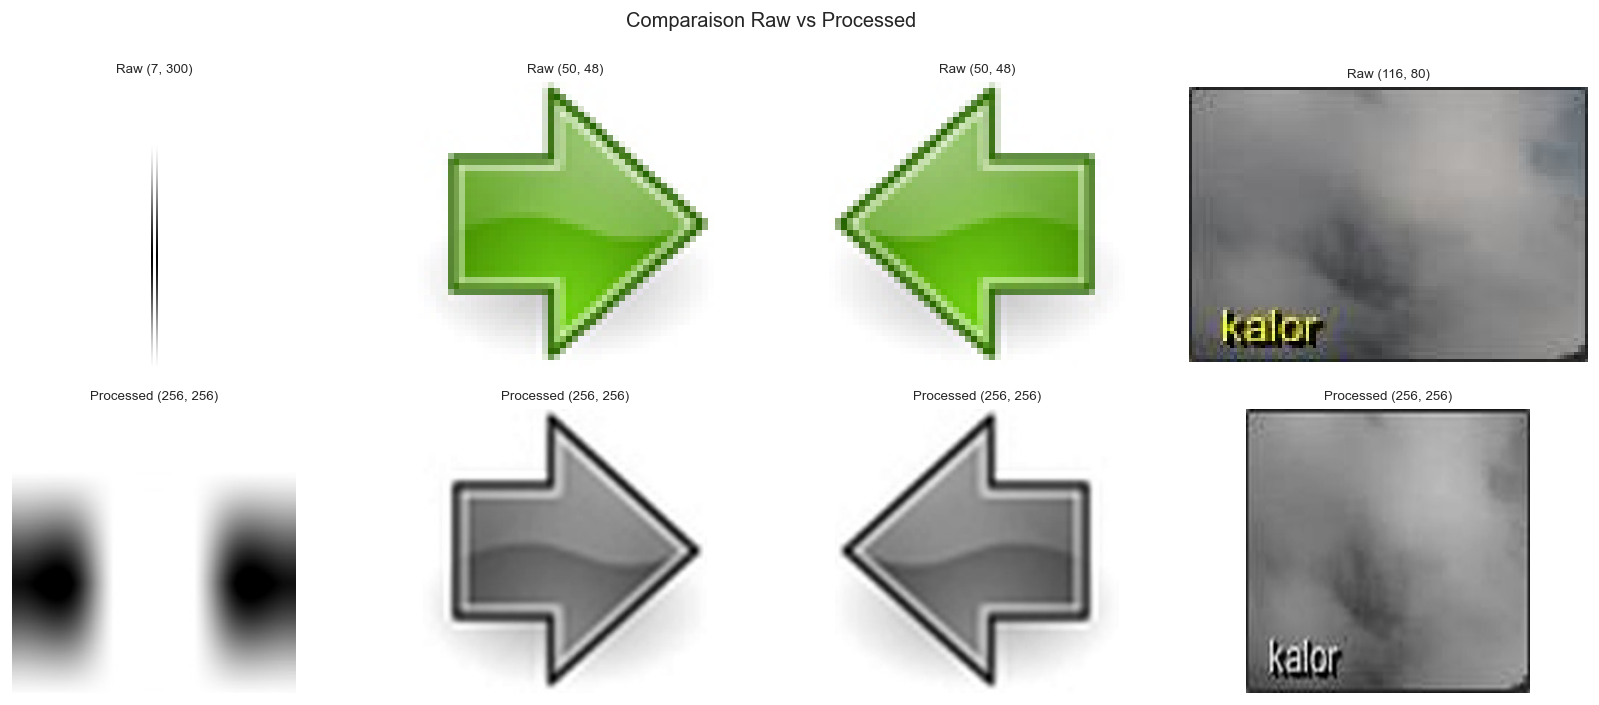

In [11]:
# [LÉGER] — Comparaison visuelle : raw vs processed
from PIL import Image as PILImage

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

shown = 0
for r in test_pp_results:
    if not r["success"] or shown >= 4:
        continue
    raw_p = Path(r["raw_path"])
    proc_p = Path(r["processed_path"])
    if raw_p.exists() and proc_p.exists():
        try:
            img_raw = PILImage.open(raw_p)
            img_proc = PILImage.open(proc_p)
            axes[0, shown].imshow(img_raw)
            axes[0, shown].set_title(f"Raw {img_raw.size}", fontsize=8)
            axes[0, shown].axis("off")
            axes[1, shown].imshow(img_proc, cmap="gray")
            axes[1, shown].set_title(f"Processed {img_proc.size}", fontsize=8)
            axes[1, shown].axis("off")
            shown += 1
        except Exception:
            continue

for i in range(shown, 4):
    axes[0, i].axis("off")
    axes[1, i].axis("off")

plt.suptitle("Comparaison Raw vs Processed", fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# [COÛTEUX] — Prétraitement complet 2014–2018
# Temps estimé : ~5-15 min selon volume et disque.
# Les images déjà traitées sont automatiquement ignorées (overwrite=False).

all_pp_results = preprocessor.process_all_months(
    year_start=YEAR_START,
    year_end=YEAR_END,
    overwrite=False,
    max_per_month=MAX_PER_MONTH,
)

# Résumé
total_pp = sum(len(v) for v in all_pp_results.values())
total_ok = sum(sum(r["success"] for r in v) for v in all_pp_results.values())
total_night = sum(
    sum(1 for r in v if r.get("is_night"))
    for v in all_pp_results.values()
)

print(f"\n{'='*50}")
print(f"PRÉTRAITEMENT TERMINÉ")
print(f"{'='*50}")
print(f"Total traité : {total_pp:,}")
print(f"Succès       : {total_ok:,}")
print(f"Échecs       : {total_pp - total_ok:,}")
print(f"Images nuit  : {total_night:,}")

15:58:22 | INFO     | src.preprocessing:238 — Prétraitement de 2 images — 2014/01
Prétraitement 2014/01: 100%|██████████| 2/2 [00:00<00:00, 7358.43it/s]
15:58:22 | INFO     | src.preprocessing:248 — Prétraitement terminé : 2 OK, 0 erreurs
15:58:22 | INFO     | src.preprocessing:238 — Prétraitement de 2 images — 2014/02
Prétraitement 2014/02: 100%|██████████| 2/2 [00:00<00:00, 8058.22it/s]
15:58:22 | INFO     | src.preprocessing:248 — Prétraitement terminé : 2 OK, 0 erreurs
15:58:22 | INFO     | src.preprocessing:238 — Prétraitement de 2 images — 2014/03
Prétraitement 2014/03: 100%|██████████| 2/2 [00:00<00:00, 2457.12it/s]
15:58:22 | INFO     | src.preprocessing:248 — Prétraitement terminé : 2 OK, 0 erreurs
15:58:22 | INFO     | src.preprocessing:238 — Prétraitement de 2 images — 2014/04
Prétraitement 2014/04: 100%|██████████| 2/2 [00:00<00:00, 7839.82it/s]
15:58:22 | INFO     | src.preprocessing:248 — Prétraitement terminé : 2 OK, 0 erreurs
15:58:22 | INFO     | src.preprocessing:238 


PRÉTRAITEMENT TERMINÉ
Total traité : 14,930
Succès       : 14,930
Échecs       : 0
Images nuit  : 0


---
## 3D — Mise à jour de l'index et rapport final

Intégrer les résultats qualité dans l'index CSV.

In [13]:
# [MOYEN] — Mise à jour de l'index avec les résultats qualité
indexer = MerapiIndexer(config)

# Fusionner tous les résultats qualité
all_results_flat = []
for results in all_quality_results.values():
    all_results_flat.extend(results)

print(f"Résultats qualité à intégrer : {len(all_results_flat):,}")

# Mettre à jour
qf.update_index_from_results(all_results_flat, indexer)

# Vérifier
df_final = indexer.load()
qf_filled = df_final["quality_flag"].notna().sum()
print(f"\nIndex après mise à jour :")
print(f"  quality_flag renseigné : {qf_filled:,} / {len(df_final):,}")
print(f"  Répartition :")
print(df_final["quality_flag"].value_counts().to_string())

Résultats qualité à intégrer : 14,930


15:58:55 | INFO     | src.quality_filter:373 — Index mis à jour : 24491 entrées quality_flag enrichies.



Index après mise à jour :
  quality_flag renseigné : 27,098 / 27,098
  Répartition :
quality_flag
usable    20246
nan        3190
dark       2759
cloudy      903


In [14]:
# [LÉGER] — Rapport final
print("=" * 60)
print("RAPPORT PHASE 3 — PRÉTRAITEMENT ET QUALITÉ")
print("=" * 60)

df_final = indexer.load()
df_2014_2018 = df_final[df_final["year"].between(YEAR_START, YEAR_END)]

n_total = len(df_2014_2018)
n_downloaded = df_2014_2018["downloaded"].sum() if "downloaded" in df_2014_2018.columns else 0
n_quality = df_2014_2018["quality_flag"].notna().sum()

print(f"""
INDEX ({YEAR_START}–{YEAR_END})
  Entrées totales  : {n_total:,}
  Sur disque       : {n_downloaded:,}
  Qualité évaluée  : {n_quality:,}
""")

if n_quality > 0:
    for qf_label in ["usable", "dark", "cloudy", "corrupted"]:
        count = (df_2014_2018["quality_flag"] == qf_label).sum()
        pct = count / n_quality * 100
        print(f"  {qf_label:12s} : {count:5,} ({pct:.1f}%)")

# Compter les images processed
total_proc_final = sum(
    len(list((PROC_DIR / str(y) / f"{m:02d}").glob("*.jpg")))
    for y in range(YEAR_START, YEAR_END + 1)
    for m in range(1, 13)
    if (PROC_DIR / str(y) / f"{m:02d}").exists()
)
print(f"\nPRÉTRAITEMENT")
print(f"  Images prétraitées : {total_proc_final:,}")
print(f"  Cible (256x256, L, minmax)")
print(f"  Formats : .jpg (visualisation) + .npy (float32 pour modèles)")

print(f"\nPROCHAINES ÉTAPES")
print(f"  → Phase 4 : Baselines (détection d'anomalies)")
print(f"  → Utiliser uniquement les images 'usable' pour l'entraînement")
print(f"  → Traiter les images 'dark' séparément si pertinent")

RAPPORT PHASE 3 — PRÉTRAITEMENT ET QUALITÉ

INDEX (2014–2018)
  Entrées totales  : 25,016
  Sur disque       : 23,815
  Qualité évaluée  : 25,016

  usable       : 20,217 (80.8%)
  dark         : 2,759 (11.0%)
  cloudy       :   903 (3.6%)
  corrupted    :     0 (0.0%)

PRÉTRAITEMENT
  Images prétraitées : 14,930
  Cible (256x256, L, minmax)
  Formats : .jpg (visualisation) + .npy (float32 pour modèles)

PROCHAINES ÉTAPES
  → Phase 4 : Baselines (détection d'anomalies)
  → Utiliser uniquement les images 'usable' pour l'entraînement
  → Traiter les images 'dark' séparément si pertinent


# 03 — Pretraitement et filtrage qualite
## Merapi Anomaly Detection — Phase 3

Objectifs : redimensionner, normaliser, classifier (usable/cloudy/dark/corrupted), mettre a jour index.

## 0. Imports

In [15]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils import load_config, setup_logger, get_index_path
from src.preprocessing import MerapiPreprocessor
from src.quality_filter import QualityFilter
from src.indexer import MerapiIndexer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110})
config = load_config()
setup_logger(config)
FIGURES_DIR = PROJECT_ROOT / config["paths"]["figures"]
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

preprocessor = MerapiPreprocessor(config)
quality_filter = QualityFilter(config)
indexer = MerapiIndexer(config)

print("Taille cible      :", config["preprocessing"]["target_size"])
print("Normalisation     :", config["preprocessing"]["normalization"])
print("Seuil nuit (lum<) :", config["preprocessing"]["night_brightness_threshold"])
print("Seuil nuage (var<):", config["preprocessing"]["cloud_variance_threshold"])


Taille cible      : [256, 256]
Normalisation     : minmax
Seuil nuit (lum<) : 30
Seuil nuage (var<): 50.0


## 1. Chargement de l index

In [16]:
index_real = get_index_path(config)
index_demo = PROJECT_ROOT / "data" / "index" / "index_demo.csv"

if index_real.exists():
    df = pd.read_csv(index_real, dtype=str, na_values=["", "None", "nan"])
    SOURCE = "reel"
else:
    df = pd.read_csv(index_demo, dtype=str, na_values=["", "None", "nan"])
    SOURCE = "demo"

for c in ["year", "month", "day", "hour", "minute"]:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
df["downloaded"] = df["downloaded"].map(lambda x: str(x).lower() == "true")
df["file_size_bytes"] = pd.to_numeric(df["file_size_bytes"], errors="coerce")
print(f"Index {SOURCE} : {len(df)} images, {df['downloaded'].sum()} telechargees")


Index reel : 27098 images, 25083 telechargees


## 2. Calibration des seuils — distribution de luminosite et variance

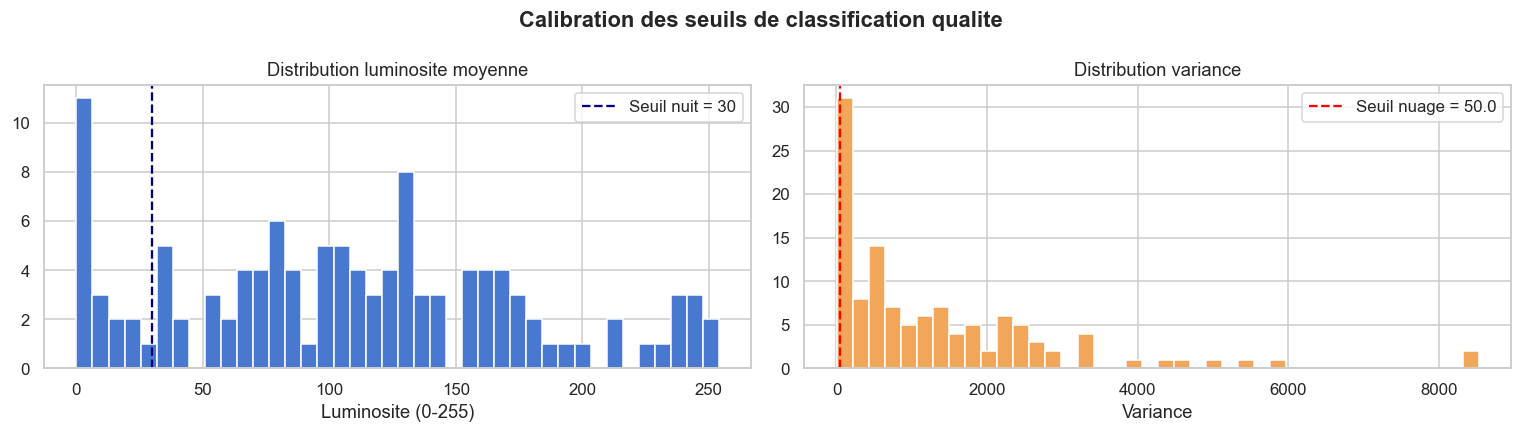

Si les seuils semblent mal places, ajustez-les dans config/settings.yaml


In [17]:
df_dl = df[df["downloaded"] == True].copy()

brightness_vals = []
for _, row in df_dl.sample(min(200, len(df_dl)), random_state=42).iterrows():
    path = PROJECT_ROOT / str(row["local_path"])
    if path.exists():
        try:
            arr = np.array(Image.open(path).convert("L"), dtype=np.float32)
            brightness_vals.append({"mean_brightness": arr.mean(), "variance": arr.var()})
        except Exception:
            pass

if brightness_vals:
    df_b = pd.DataFrame(brightness_vals)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(df_b["mean_brightness"], bins=40, color="#4878CF", edgecolor="white")
    axes[0].axvline(config["preprocessing"]["night_brightness_threshold"],
                    color="navy", linestyle="--",
                    label=f"Seuil nuit = {config['preprocessing']['night_brightness_threshold']}")
    axes[0].set_title("Distribution luminosite moyenne")
    axes[0].set_xlabel("Luminosite (0-255)")
    axes[0].legend()

    axes[1].hist(df_b["variance"], bins=40, color="#F2A65A", edgecolor="white")
    axes[1].axvline(config["preprocessing"]["cloud_variance_threshold"],
                    color="red", linestyle="--",
                    label=f"Seuil nuage = {config['preprocessing']['cloud_variance_threshold']}")
    axes[1].set_title("Distribution variance")
    axes[1].set_xlabel("Variance")
    axes[1].legend()

    plt.suptitle("Calibration des seuils de classification qualite", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "10_threshold_calibration.png", bbox_inches="tight")
    plt.show()
    print("Si les seuils semblent mal places, ajustez-les dans config/settings.yaml")
else:
    print("Aucune image locale. Lancez test_phase1.py --max-images 50")


## 3. Pipeline de preprocessing sur un exemple

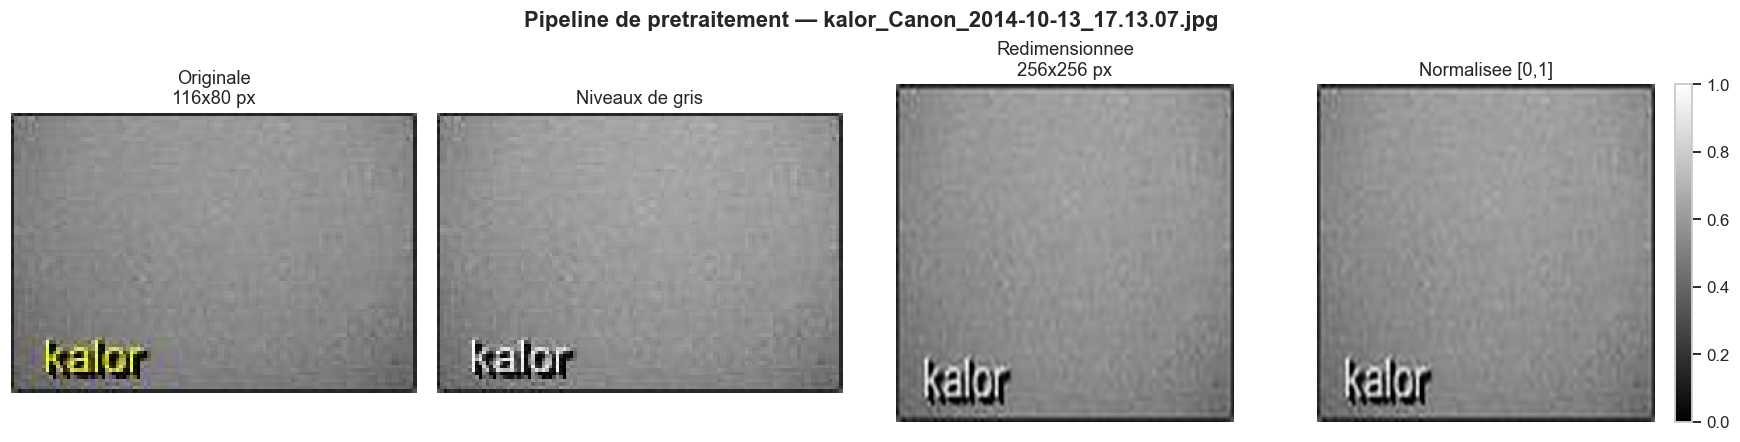

In [18]:
def show_preprocessing_pipeline(raw_path, config):
    if not Path(raw_path).exists():
        print("Image non trouvee :", raw_path)
        return
    img_orig = Image.open(raw_path)
    target_size = tuple(config["preprocessing"]["target_size"])

    img_gray = img_orig.convert("L")
    img_resized = img_gray.resize(target_size, Image.LANCZOS)
    arr = np.array(img_resized, dtype=np.float32)
    arr_min, arr_max = arr.min(), arr.max()
    arr_norm = (arr - arr_min) / max(arr_max - arr_min, 1e-6)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_orig, cmap="gray")
    axes[0].set_title(f"Originale\n{img_orig.size[0]}x{img_orig.size[1]} px")
    axes[1].imshow(img_gray, cmap="gray")
    axes[1].set_title("Niveaux de gris")
    axes[2].imshow(arr, cmap="gray")
    axes[2].set_title(f"Redimensionnee\n{target_size[0]}x{target_size[1]} px")
    im = axes[3].imshow(arr_norm, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("Normalisee [0,1]")
    plt.colorbar(im, ax=axes[3], fraction=0.046)
    for ax in axes: ax.axis("off")
    plt.suptitle(f"Pipeline de pretraitement — {Path(raw_path).name}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"11_preproc_{Path(raw_path).stem[:25]}.png", bbox_inches="tight")
    plt.show()

# Appliquer sur les premieres images disponibles
df_sample = df[df["downloaded"] == True].head(3)
for _, row in df_sample.iterrows():
    path = PROJECT_ROOT / str(row["local_path"])

    if path.exists():
        show_preprocessing_pipeline(path, config)
        break


## 4. Application du pipeline complet

In [19]:
# Choisir le mois a traiter
YEAR, MONTH = 2014, 11

print(f"Pretraitement {YEAR}/{MONTH:02d}...")
preprocessing_results = preprocessor.process_month(YEAR, MONTH, overwrite=False)

if preprocessing_results:
    n_ok = sum(r["success"] for r in preprocessing_results)
    n_night = sum(r.get("is_night", False) for r in preprocessing_results if r["success"])
    print(f"{n_ok}/{len(preprocessing_results)} images pretraitees")
    print(f"  dont {n_night} nocturnes ({n_night/max(n_ok,1)*100:.1f}%)")
else:
    print("Aucune image brute trouvee pour ce mois.")
    print("Lancez : python test_phase1.py --max-images 50")


15:59:16 | INFO     | src.preprocessing:238 — Prétraitement de 119 images — 2014/11


Pretraitement 2014/11...


Prétraitement 2014/11: 100%|██████████| 119/119 [00:00<00:00, 7150.65it/s]
15:59:16 | INFO     | src.preprocessing:248 — Prétraitement terminé : 119 OK, 0 erreurs


TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

In [20]:
print(f"Classification qualite pour {YEAR}/{MONTH:02d}...")
quality_results = quality_filter.classify_month(YEAR, MONTH)

if quality_results:
    report = quality_filter.quality_report(quality_results)
    print("Rapport qualite :")
    for flag, count in report.get("by_quality", {}).items():
        pct = count / report["total"] * 100
        print(f"  {flag:12s} : {count:4d}  ({pct:.1f}%)")
    quality_filter.update_index_from_results(quality_results, indexer)
    print("Index mis a jour avec les flags de qualite")


15:59:26 | INFO     | src.quality_filter:219 — Classification qualité de 119 images — 2014/11


Classification qualite pour 2014/11...


Qualité 2014/11: 100%|██████████| 119/119 [00:00<00:00, 598.45img/s]
15:59:26 | INFO     | src.quality_filter:447 — Qualité 2014/11 (119 images) :
15:59:26 | INFO     | src.quality_filter:450 —   usable       :  118  (99.2%)
15:59:26 | INFO     | src.quality_filter:450 —   dark         :    1  (0.8%)
15:59:26 | INFO     | src.quality_filter:451 —   Taux utilisables : 99.2%


Rapport qualite :
  usable       :  118  (99.2%)
  dark         :    1  (0.8%)


15:59:27 | INFO     | src.quality_filter:373 — Index mis à jour : 235 entrées quality_flag enrichies.


Index mis a jour avec les flags de qualite


## 5. Visualisation de l espace features qualite

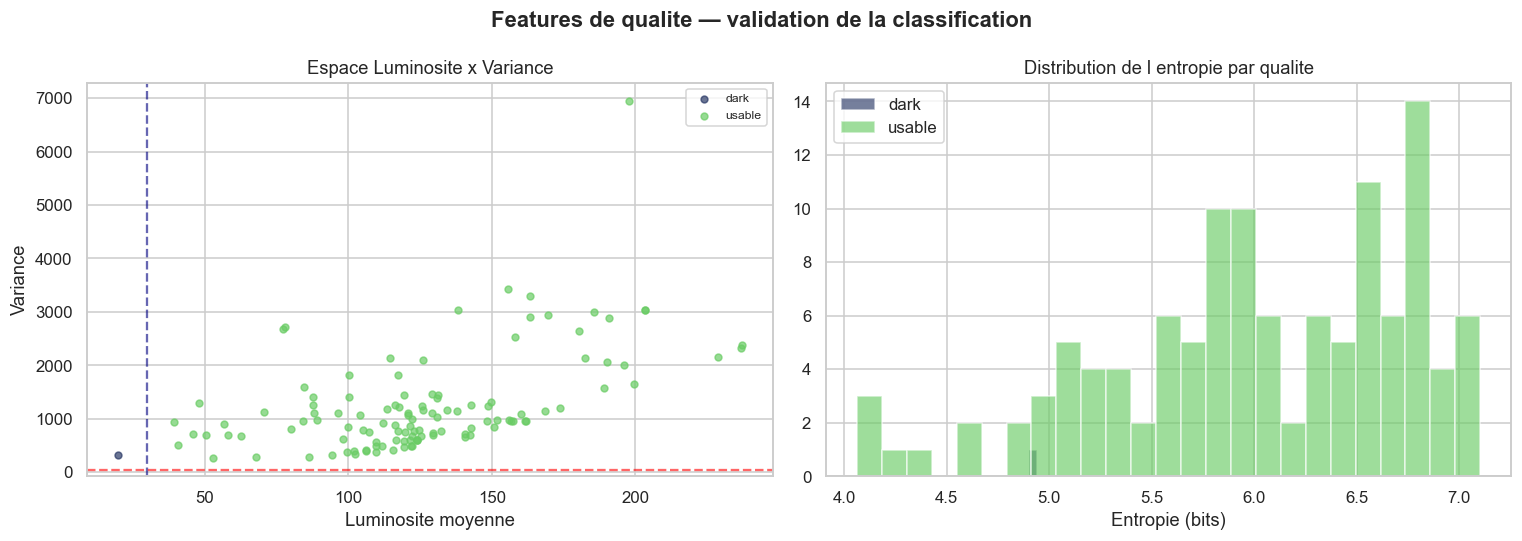

In [21]:
if quality_results:
    df_q = pd.DataFrame(quality_results).dropna(subset=["mean_brightness"])

    COLORS_Q = {
        "usable": "#6ACC65", "cloudy": "#9B9B9B",
        "dark": "#2B3A67", "corrupted": "#E24B4A", "unknown": "#FAC775",
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for flag, grp in df_q.groupby("quality_flag"):
        axes[0].scatter(grp["mean_brightness"], grp["variance"],
                        c=COLORS_Q.get(flag, "gray"), label=flag, alpha=0.7, s=20)
    axes[0].axvline(config["preprocessing"]["night_brightness_threshold"],
                    color="navy", linestyle="--", alpha=0.6)
    axes[0].axhline(config["preprocessing"]["cloud_variance_threshold"],
                    color="red", linestyle="--", alpha=0.6)
    axes[0].set_xlabel("Luminosite moyenne")
    axes[0].set_ylabel("Variance")
    axes[0].set_title("Espace Luminosite x Variance")
    axes[0].legend(fontsize=8)

    if "entropy" in df_q.columns and df_q["entropy"].notna().any():
        for flag, grp in df_q.groupby("quality_flag"):
            axes[1].hist(grp["entropy"].dropna(), bins=25, alpha=0.65,
                         color=COLORS_Q.get(flag, "gray"), label=flag)
        axes[1].set_title("Distribution de l entropie par qualite")
        axes[1].set_xlabel("Entropie (bits)")
        axes[1].legend()

    plt.suptitle("Features de qualite — validation de la classification", fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "12_quality_feature_space.png", bbox_inches="tight")
    plt.show()


## 6. Note sur la ROI volcanique

In [22]:
roi_cfg = config["preprocessing"]["roi"]
print("ROI volcanique — etat actuel :", roi_cfg["enabled"])
print()
print("Pour activer la ROI dans config/settings.yaml :")
print("  preprocessing:")
print("    roi:")
print("      enabled: true")
print("      x_min: <valeur pixel>")
print("      y_min: <valeur pixel>")
print("      x_max: <valeur pixel>")
print("      y_max: <valeur pixel>")
print()
print("Conseil : definir avec expertise volcanologique")
print("          en centrant sur le dome sommital du Merapi.")


ROI volcanique — etat actuel : False

Pour activer la ROI dans config/settings.yaml :
  preprocessing:
    roi:
      enabled: true
      x_min: <valeur pixel>
      y_min: <valeur pixel>
      x_max: <valeur pixel>
      y_max: <valeur pixel>

Conseil : definir avec expertise volcanologique
          en centrant sur le dome sommital du Merapi.


## 7. Bilan

In [23]:
indexer.print_summary()

df_updated = indexer.load()
df_usable = df_updated[df_updated["quality_flag"] == "usable"]
df_dark = df_updated[df_updated["quality_flag"] == "dark"]
df_cloudy = df_updated[df_updated["quality_flag"] == "cloudy"]

print()
print("=" * 55)
print("CORPUS PRETS POUR LA PHASE 4 (BASELINES)")
print("=" * 55)
print(f"  Diurne utilisable : {len(df_usable)} images")
print(f"  Nocturne (dark)   : {len(df_dark)} images")
print(f"  Nuageuses (exclu) : {len(df_cloudy)} images")
print()
print("Formats disponibles dans data/processed/YYYY/MM/ :")
print("  .jpg  -> image visualisable (uint8)")
print("  .npy  -> array float32 normalise [0,1] (pour les modeles)")
print()
print("Etape suivante : notebook 04_baselines.ipynb")


15:59:33 | INFO     | src.indexer:329 — ==================================================
15:59:33 | INFO     | src.indexer:330 — Index Merapi — résumé
15:59:33 | INFO     | src.indexer:331 —   Total indexé   : 27098
15:59:33 | INFO     | src.indexer:332 —   Téléchargé     : 25083
15:59:33 | INFO     | src.indexer:333 —   Non téléchargé : 2015
15:59:33 | INFO     | src.indexer:334 —   Qualité        : {'usable': 20246, 'nan': 3190, 'dark': 2759, 'cloudy': 903}
15:59:33 | INFO     | src.indexer:335 —   Par année      : {np.int64(2014): 844, np.int64(2015): 2286, np.int64(2016): 7805, np.int64(2017): 6965, np.int64(2018): 7116, np.int64(2019): 2082}
15:59:33 | INFO     | src.indexer:336 — ==================================================



CORPUS PRETS POUR LA PHASE 4 (BASELINES)
  Diurne utilisable : 20246 images
  Nocturne (dark)   : 2759 images
  Nuageuses (exclu) : 903 images

Formats disponibles dans data/processed/YYYY/MM/ :
  .jpg  -> image visualisable (uint8)
  .npy  -> array float32 normalise [0,1] (pour les modeles)

Etape suivante : notebook 04_baselines.ipynb
